# Основные сведения о библиотеке GeoPandas

## 📚 Основные сведения о библиотеке GeoPandas

### 🔹 Что такое GeoPandas? {.unnumbered}

**GeoPandas** — это расширение библиотеки **Pandas**, предназначенное для работы с **геопространственными данными** (векторными: точки, линии, полигоны).

Она добавляет к обычным таблицам Pandas возможность хранить и обрабатывать **геометрические объекты** (например, координаты зданий, границы районов, маршруты).

При работе с `genesis` он играет роль инструмента оперирования геопространственными данными, такими как здания и сооружения в населенном пункте, границы населенных пунктов, размещение ПСЧ и т.д.

---

### 🔹 Основные возможности: {.unnumbered}

| Возможность | Описание |
|------------|----------|
| 🗺️ Работа с геометриями | Поддерживает точки, линии, полигоны и их комбинации |
| 🧭 Системы координат | Поддержка систем координат (СК или CRS), преобразование между ними |
| 📦 Форматы данных | Чтение/запись файлов: GeoJSON, Shapefile, GPKG, KML, CSV + геоданные и др. |
| 📊 Пространственные операции | Пересечение, объединение, буферизация, поиск ближайших объектов и т.д. |
| 🎨 Визуализация | Простая отрисовка карт на основе Matplotlib |
| 🧩 Интеграция | Работает с другими библиотеками: OSMnx, Folium, Shapely, PyProj и др. |

---

### 🔹 Основные объекты GeoPandas: {.unnumbered}

| Объект | Описание |
|--------|----------|
| `GeoSeries` | Коллекция геометрических объектов (точки, линии, полигоны) |
| `GeoDataFrame` | Расширенная версия DataFrame из Pandas, с одной колонкой геометрии (`geometry`) |

---

### 🔹 Примеры использования: {.unnumbered}

- Загрузка и анализ границ регионов, городов
- Работа с точками интереса (POI), например, места размещения ПСЧ, места ДТП, точки размещения населенных пунктов на картах мелких масштабов
- Анализ пространственных взаимосвязей (что находится рядом? связывание зданий с узлами ГДС)
- Сохранение результатов в форматах ГИС
- Построение интерактивных карт
- Интеграция с библиотеками анализа дорожных сетей (например, `OSMnx`)

---

### 🔹 Пример кода: {.unnumbered}

```python
import geopandas as gpd

# 1. Загрузка данных (например, Shapefile или GeoJSON)
gdf = gpd.read_file('data/buildings_sosnovoborsk.gpkg')

# 2. Фильтрация данных
schools = gdf[gdf['building'] == 'school']

# 3. Преобразование системы координат (например, в метры)
schools = schools.to_crs(epsg=3857)

# 4. Визуализация
schools.plot(edgecolor='black', facecolor='lightgray', alpha=0.7)
```

---

### 🔹 Полезные функции: {.unnumbered}

| Функция | Назначение |
|--------|-----------|
| `gpd.read_file()` | Загружает данные из файла (GeoJSON, Shapefile и др.) |
| `.to_crs()` | Изменяет систему координат |
| `.buffer()` | Создаёт буфер вокруг геометрии |
| `.intersects()`, `.within()`, `.contains()` | Пространственные проверки |
| `.sjoin()` | Пространственное соединение двух наборов данных |
| `.plot()` | Отрисовка геометрии на графике |
| `.to_file()` | Сохраняет данные в файл (GeoJSON, GPKG и др.) |

---

### 🔹 Техническая информация: {.unnumbered}

| Характеристика | Описание |
|----------------|----------|
| Язык программирования | Python |
| Лицензия | BSD License (открытый исходный код) |
| Авторы | Кевин Кершнер, Дэн Аллен и др. |
| Документация | [https://geopandas.org](https://geopandas.org) |
| Установка | `pip install geopandas` или `conda install -c conda-forge geopandas` |
| Зависимости | Pandas, Shapely, Fiona, PyProj, Matplotlib |

## Основные примеры использования библиотеки geopandas

### Загрузка и сохранение файлов {.unnumbered}

Существует большое количество различных форматов хранения пространственных данных. В рамках работы с `genesis` формат `geopackage` является предпочтительным.

**GeoPackage** — это **открытый, платформенно-независимый формат хранения геопространственных данных**, основанный на `SQLite`.  
Он разработан [OGC](https://www.ogc.org/) (Open Geospatial Consortium) как универсальная альтернатива устаревшим форматам, таким как Shapefile.

**Основные особенности:**

| Характеристика | Описание |
|----------------|----------|
| 🗂 Единый файл | Все данные (геометрии, атрибуты, стили, метаданные) хранятся в одном `.gpkg` файле |
| 📦 Поддержка типов данных | Векторные данные (точки, линии, полигоны), растры (в виде тайлов), таблицы атрибутов |
| 🌐 Открытый стандарт | Поддерживается QGIS, ArcGIS, GDAL, OGR и другими ГИС-программами |
| 📁 Нет внешних файлов | В отличие от Shapefile, GPKG не требует множества сопутствующих файлов (.shx, .dbf и др.) |
| 📙 Поддержка нескольких слоёв | В одном файле может храниться несколько наборов данных (слоёв) |
| 🧭 Поддержка CRS | Хранение и преобразование систем координат |
| 💾 Легко редактируется | Можно открывать и изменять в SQLite-редакторах |
| 🔀 Распределенный доступ | Работать с файлом могут одноврменно несколько пользователей. В том числе допускается одновременная работа с файлом при помощи скриптов `Python` и приложения `QGIS` |

In [2]:
import geopandas as gpd

# Загрузка данных из файла geopackage
gdf = gpd.read_file('data/buildings_sosnovoborsk.gpkg')

# Печать первых двух строк данных
gdf.head(2)

,id,name,amenity,building,addr:street,addr:housenumber,building:levels,building:flats,nearest_node,geometry
0,1597824,None,None,school,Весенняя улица,3,3,None,1545611829,"POLYGON ((93.33569 56.11617, 93.33561 56.11612..."
1,1597831,None,None,school,улица 9-й Пятилетки,24,3,None,5574240334,"POLYGON ((93.33089 56.12099, 93.33045 56.12069..."


In [3]:
# Сохранение данных в файл geopackage
# layer - имя слоя в файле
# driver - тип файла (GPKG - geopackage)
gdf.to_file('data/buildings_sosnovoborsk_save.gpkg', layer='buildings', driver='GPKG')

### Структура данных {.unnumbered}

Основными структурами данных в `geopandas` являются: `GeoSeries`, `GeoDataFrame`.

`GeoDataFrame` - это таблица в которой строки отражают отдельные объекты, а столбцы - свойства этих объектов.

Например:

In [4]:
# Печать основных сведений о наборе данных
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   id                600 non-null    int64   
 1   name              24 non-null     object  
 2   amenity           7 non-null      object  
 3   building          600 non-null    object  
 4   addr:street       358 non-null    object  
 5   addr:housenumber  357 non-null    object  
 6   building:levels   375 non-null    object  
 7   building:flats    7 non-null      object  
 8   nearest_node      600 non-null    int64   
 9   geometry          600 non-null    geometry
dtypes: geometry(1), int64(2), object(7)
memory usage: 47.0+ KB


В наборе данных `gdf` имеются сведения о 600 зданиях.

Набор имеет 10 столбцов:

Каждый из столбцов отражает некоторое атрибутивное свойство зданий.

| № | Название | Тип данных | Количество заполненных | Описание |
|---|----------|------------|------------------------|----------|
| 0 | `id` | `int64` | 600 (все) | Уникальный идентификатор здания или объекта |
| 1 | `name` | `object` | 24 | Название объекта (не у всех объектов указано) |
| 2 | `amenity` | `object` | 7 | Тип здания (например, "school", "hospital") |
| 3 | `building` | `object` | 600 (все) | Назначение здания (например, "residential" - жилое) |
| 4 | `addr:street` | `object` | 358 | Имя улицы |
| 5 | `addr:housenumber` | `object` | 357 | Номер дома |
| 6 | `building:levels` | `object` | 375 | Количество этажей в здании |
| 7 | `building:flats` | `object` | 7 | Примерное количество квартир |
| 8 | `nearest_node` | `int64` | 600 (все) | Идентификатор ближайшего узла дорожной сети (из графа OSMnx) |
| 9 | `geometry` | `geometry` | 600 (все) | Геометрия объекта (обычно полигон — контур здания) |

Каждый из столбцов представляет собой другую структуру - `GeoSeries`.

Принципиально важным столбцом как для `GeoDataFrame` является `geometry` - `GeoSeries` содержащее описание геометрии объекта.

### О системах координат (СК) {.unnumbered}

Все наборы пространственных данных имеют свойство `.crs` описывающее СК набора. Следует с большой внимательностью относиться к этому свойству, т.к. для корректного расчета размеров и площадей наборы должны быть перепроецированы в локальные СК, в то время, как ГИС как правило оперируют географическими СК (с единицами измерения в градусах, минутах и секундах).

Более подробно о СК можно прочесть в русскоязычной документации `QGIS`: https://docs.qgis.org/3.40/ru/docs/gentle_gis_introduction/coordinate_reference_systems.html 

И в документации `Geopandas`: https://geopandas.org/en/stable/docs/user_guide/projections.html.

Для перепроецирования `GeoDataFrame` в другую СК можно воспользоваться методом geopandas `.to_crs()` или методом `osmnx` `osmnx.projection.project_gdf()`

In [5]:
# Печать текущей СК
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Исходно набор данных о зданиях находится в СК `EPSG:4326` - наиболее распространенной для хранения географических данных.

In [6]:
# Площадь 1-го здания в наборе
print('Площадь здания в начальной СК:', gdf.area[0])

# Перепроецирование, способ №1
gdf1 = gdf.copy()
gdf1 = gdf1.to_crs('EPSG:32646')
print(f'1. Площадь здания в локальной СК [{gdf1.crs}]:', gdf1.area[0], 'м.кв.')

# Перепроецирование, способ №2
import osmnx as ox
gdf1 = gdf.copy()
gdf1 = ox.projection.project_gdf(gdf1)
print(f'2. Площадь здания в локальной СК [{gdf1.crs}]:', gdf1.area[0], 'м.кв.')

C:\Users\obsid\AppData\Local\Temp\ipykernel_12388\4164851771.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print('Площадь здания в начальной СК:', gdf.area[0])


Площадь здания в начальной СК: 4.313685249988263e-07
1. Площадь здания в локальной СК [EPSG:32646]: 2985.409683588975 м.кв.
2. Площадь здания в локальной СК [EPSG:32646]: 2985.409683588975 м.кв.


Можно взглянуть в каком виде хранятся данные о геометрии одного и того же объекта в разных системах координат.

In [10]:
print(f'СК: {gdf.crs}:')
print(gdf.geometry.loc[0])

print(f'СК: {gdf1.crs}:')
print(gdf1.geometry.loc[0])

СК: EPSG:4326:
POLYGON ((93.3356898 56.1161702, 93.3356137 56.1161191, 93.33628 56.1158106, 93.3362646 56.1158003, 93.3363401 56.1157649, 93.3363759 56.1157875, 93.3365792 56.1156944, 93.3364193 56.1155888, 93.3361391 56.1157161, 93.3358254 56.1155054, 93.3351606 56.1158132, 93.3354336 56.1159965, 93.3350542 56.1161721, 93.335312 56.1163451, 93.3356898 56.1161702), (93.335718 56.1159394, 93.3354904 56.1157866, 93.3357594 56.1156621, 93.3359871 56.1158149, 93.335718 56.1159394))
СК: EPSG:32646:
POLYGON ((520873.349172701 6219059.901338982, 520868.64491611737 6219054.190963395, 520910.2429373807 6219020.056993134, 520909.2909388074 6219018.905951147, 520914.0047896376 6219014.988854271, 520916.2186047087 6219017.515053166, 520928.9104973579 6219007.214777921, 520919.0250512997 6218995.413161619, 520901.5328913497 6219009.496588812, 520882.14084060956 6218985.951000615, 520840.6363669576 6219020.007785678, 520857.512565802 6219040.491302889, 520833.8264103742 6219059.920757498, 520849.762

Можно заметить, что неперепроецированный набор данных о зданиях содержит сведения о точках полигона в десятичном виде (градусы), в то время как, перепроецированный набор - в метрах.

Если наиболее подходящая СК не известна можно воспользоваться функцией `geopandas.estimate_utm_crs()`.

In [11]:
# Получение наиболее подходящей СК
crs = gdf.estimate_utm_crs()

# Перепроецирование, способ №3
gdf1 = gdf.copy()
gdf1 = gdf1.to_crs(crs)
print(f'3. Площадь здания в локальной СК [{gdf1.crs}]:', gdf1.area[0], 'м.кв.')

3. Площадь здания в локальной СК [EPSG:32646]: 2985.409683588975 м.кв.


### Получение некоторых свойств наборов пространственных данных {.unnumbered}

In [13]:
# Площадь первых 5 объектов
print((gdf1.area[:5]))

0    2985.409684
1    4719.062000
2    2829.825096
3    3732.893544
4    2675.150228
dtype: float64


In [14]:
# Площадь всех объектов
print(gdf1.area.sum())

785939.4238044849


In [15]:
# или
print(gdf1.geometry.union_all().area)

783857.5992423068


In [16]:
# Границы набора данных
print(gdf.total_bounds)

[93.3168948 56.1059388 93.3823154 56.1461617]


In [17]:
# Печать количества объектов каждого назначения
print('Количество объектов каждого назначения:', gdf1['building'].value_counts())

Количество объектов каждого назначения: building
yes               183
apartments        149
house              95
garages            40
detached           38
service            24
industrial         19
public             11
school              9
kindergarten        9
store               8
retail              4
church              2
hospital            2
stable              1
transportation      1
residential         1
garage              1
office              1
manufacture         1
roof                1
Name: count, dtype: int64


### Печать набора данных {.unnumbered}

Базовая печать

<Axes: >

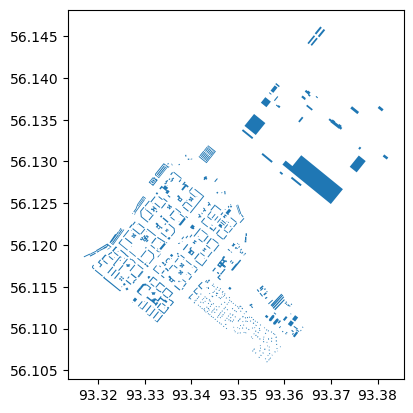

In [41]:
gdf.plot()

Печать с легендой

<Axes: >

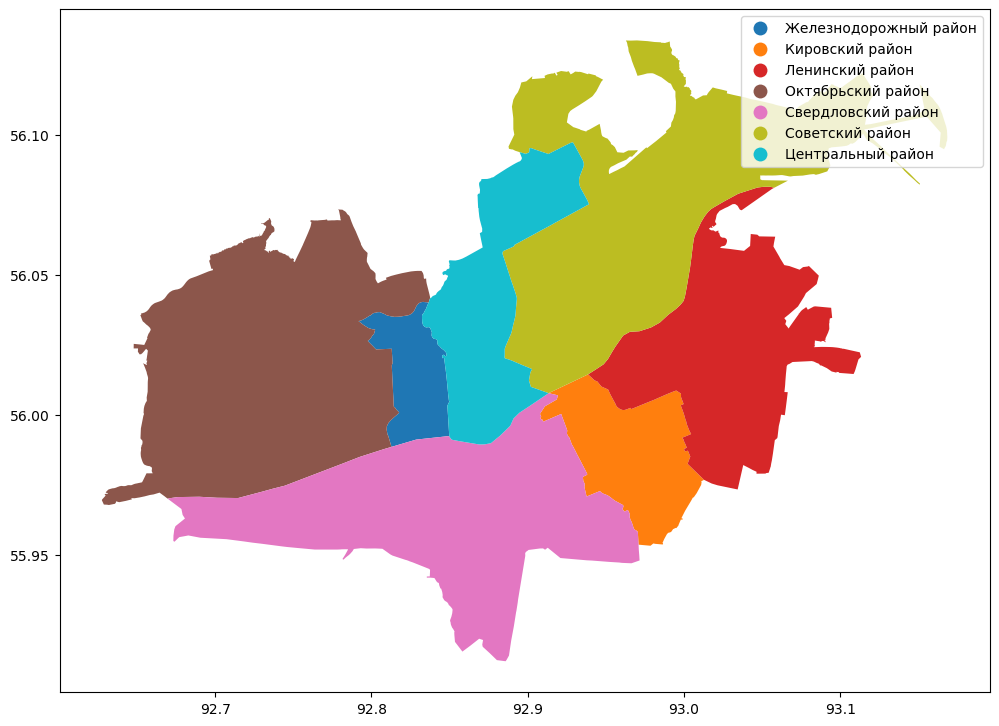

In [51]:
# Загрузка районов Красноярска
districts = gpd.read_file('data/districts.gpkg')

# Печать
districts.plot(column='name', legend=True, figsize=(12, 12))

Интерактивная карта

In [54]:
districts.explore(column='name')

Печать границ.

<Axes: >

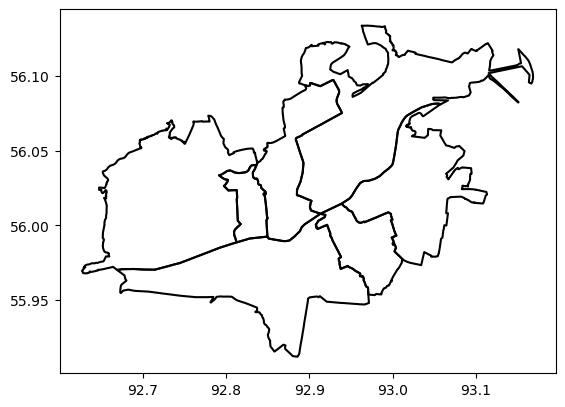

In [55]:
districts.boundary.plot(color='black')

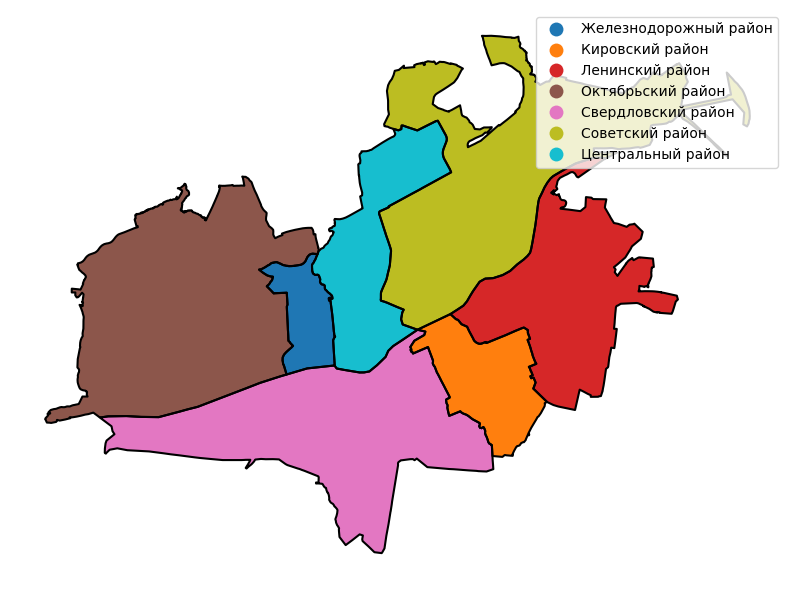

In [57]:
ax = districts.plot(column='name', legend=True, figsize=(10, 10))
districts.boundary.plot(ax=ax, color='black')
ax.set_axis_off()

### Буфер {.unnumbered}

<Axes: >

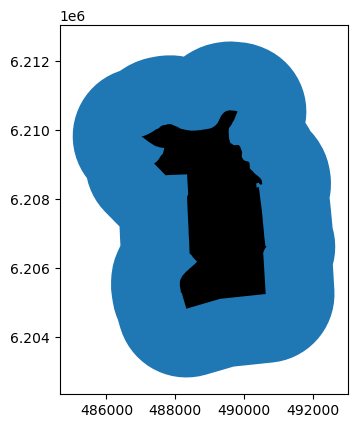

In [64]:
districts = districts.to_crs('epsg:32646')
districts_buffer = districts.buffer(2000)
ax = districts_buffer.iloc[[0]].plot()
districts.iloc[[0]].plot(ax=ax, color='black')

### Центроиды {.unnumbered}

<Axes: >

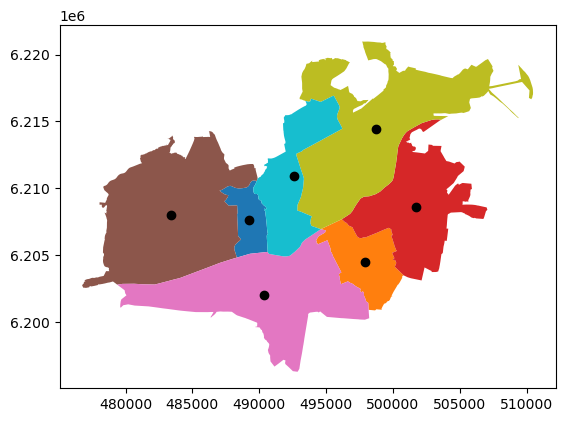

In [ ]:
# Получение точек в центре геометрии
centroids = districts.centroid

# Печать результата
ax = districts.plot(column='name')
centroids.plot(ax=ax, color='black')

### Выпуклая оболочка {.unnumbered}

<Axes: >

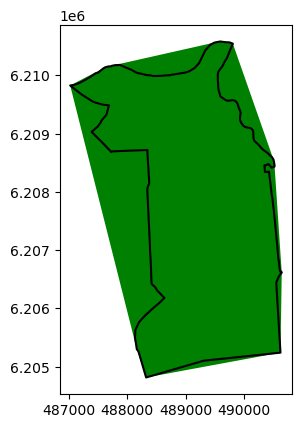

In [85]:
ax = districts.convex_hull.iloc[[0]].plot(color='green')
districts.boundary.iloc[[0]].plot(ax=ax, color='black')

### Объединение геометрии {.unnumbered}

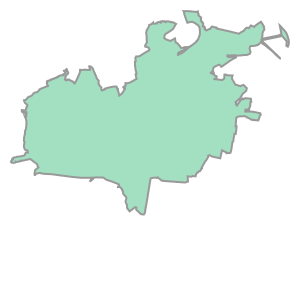

In [ ]:
city = districts.union_all()
city

::: {.callout-important}

### Важно

Результатом `.union_all()` является не `GeoDataFrame`, а объект типа `Polygon`. Использовать его можно например для передачи в качестве параметра для `ox.graph_from_polygon()`.

:::

### Соотнесение объектов из разных слоев {.unnumbered}

Определение к какому району относится то или иное здание.

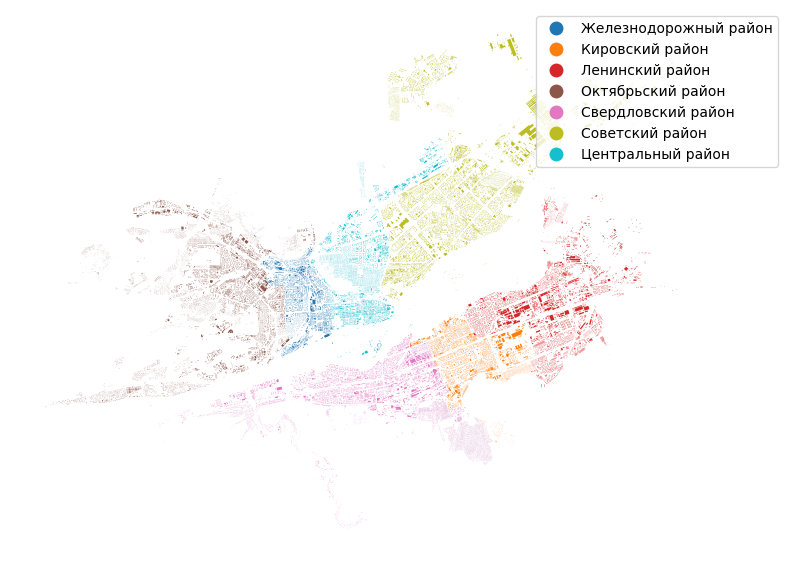

In [ ]:
# Загрузка зданий в Красноярске
buildings = gpd.read_file('data/bld.gpkg')

# Загрузка районов Красноярска
districts = gpd.read_file('data/districts.gpkg')

# Приведение к одной СК
buildings = buildings.to_crs('EPSG:32646')
districts = districts.to_crs('EPSG:32646')


# Определение, в каком районе находится каждое здание
buildings = buildings.sjoin(districts[['name', 'geometry']], how='left')

# Переименуем столбец с названиями районов
buildings.rename(columns={'name_right': 'district'}, inplace=True)


# Печать карты со зданиями соотнесенными по цветам с районом
ax = buildings.plot(column='district', legend=True, figsize=(10, 10))
ax.set_axis_off()

### Определение ближайших к зданиям узлов ГДС {.unnumbered}

In [ ]:
# Загрузка зданий сосновоборска
buildings = gpd.read_file('data/buildings_sosnovoborsk.gpkg')

# Загружаем ГДС Сосновоборска
G = ox.load_graphml(filepath="data/graph_sosnovoborsk.ml")

# Перепроецируем данные в общую СК
buildings = buildings.to_crs('EPSG:32646')
G = ox.project_graph(G, to_crs='EPSG:32646')

# Получаем  набор данных узлов графа
nodes = ox.graph_to_gdfs(G, edges=False)

# Находим ближайшие узлы графа (в наборе данных nodes ключевым узлом является osmid)
buildings = buildings.sjoin_nearest(nodes[['geometry']], how='left')

# Просмотр результатов
buildings[['building', 'addr:street', 'addr:housenumber', 'osmid']].sample(5)

,building,addr:street,addr:housenumber,osmid
35,yes,улица Ленинского Комсомола,21,1543970277
75,apartments,улица Энтузиастов,9,1545626735
486,yes,Майский переулок,32,5703333238
463,yes,None,None,1552046384
268,yes,улица 9-й Пятилетки,1,3134691195


Теперь по полю `osmid` можно найти ближайший к каждому из зданий узел ГДС.

### Сохранение данных {.unnumbered}

In [ ]:
# Сохранение в формат geopackage
# layer - имя слоя в файле
# driver - тип файла (GPKG - geopackage)
gdf.to_file('data/buildings_sosnovoborsk_save.gpkg', layer='buildings', driver='GPKG')

# Сохранение в формат shapefile
gdf.to_file('data/buildings_sosnovoborsk_save.shp', driver='ESRI Shapefile')

## Дополнительно

С основами манипуляции данными (сортировка, отбор, группировка, анализ, изменение и удаление данных и т.д.) с использованием библиотеки `pandas`, являющейся основой для `geopandas` можно ознакомиться в следующих источниках:

* [https://education.yandex.ru/handbook/python/article/modul-pandas](https://education.yandex.ru/handbook/python/article/modul-pandas)
* [https://habr.com/ru/companies/ruvds/articles/494720/](https://habr.com/ru/companies/ruvds/articles/494720/)